*  DSC680-T302 Applied Data Science (2265-1)
*  Project 1 - Analyzing Factors That Influence Retail Sales Performance
*  Charles Sarratt

# Project 1 – Retail Sales Analysis

## Objective
The objective of this analysis is to identify the factors that influence retail sales performance and evaluate whether sales outcomes can be predicted using available variables such as product category, region, and quantity.

## Data Loading and Initial Inspection

The dataset was loaded and reviewed to understand its structure, variable types, and overall composition.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

df = pd.read_csv("train.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

## Data Preparation

The order date was converted into datetime format to allow for time-based analysis. Additional features such as year and month were created.

In [2]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

## Sales by Category

This visualization shows the total sales distribution across product categories.

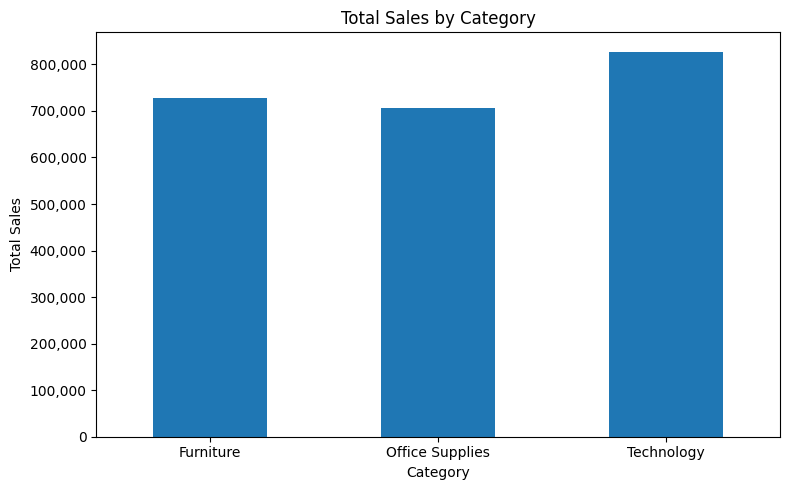

In [3]:
plt.figure(figsize=(8,5))

df.groupby('Category')['Sales'].sum().plot(kind='bar')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()

plt.show()

### Interpretation
Technology generates the highest total sales, followed by Furniture and Office Supplies. The difference between categories suggests that product type plays a meaningful role in overall revenue performance. This indicates that certain categories may be more profitable or in higher demand, making them important areas for further analysis.

## Sales by Region

This visualization shows how total sales are distributed across geographic regions.

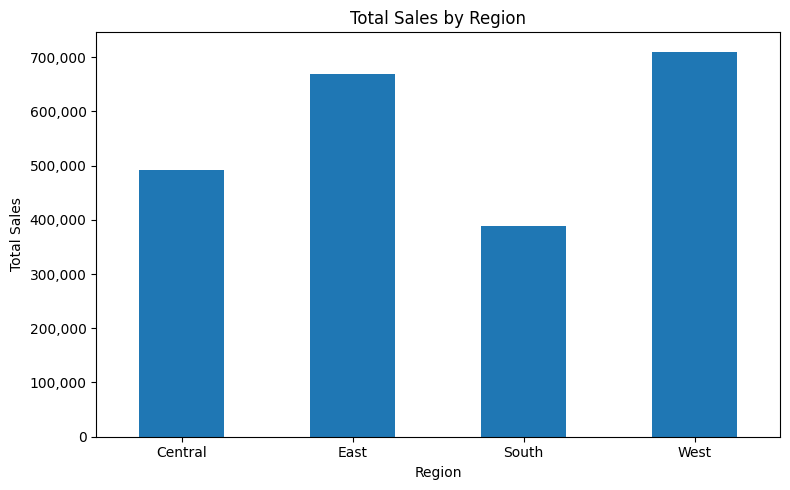

In [4]:
plt.figure(figsize=(8,5))

df.groupby('Region')['Sales'].sum().plot(kind='bar')

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()

plt.show()

### Interpretation

The West region generates the highest total sales, followed closely by the East region. In contrast, the South region has the lowest overall sales, with the Central region falling in between. 

These differences suggest that geographic location plays a significant role in sales performance. Regions with higher sales may reflect stronger market demand, larger customer bases, or more effective distribution strategies. This indicates that regional factors should be considered when analyzing and predicting retail sales outcomes.

## Sales Over Time

This visualization shows how total sales change over time based on order date.

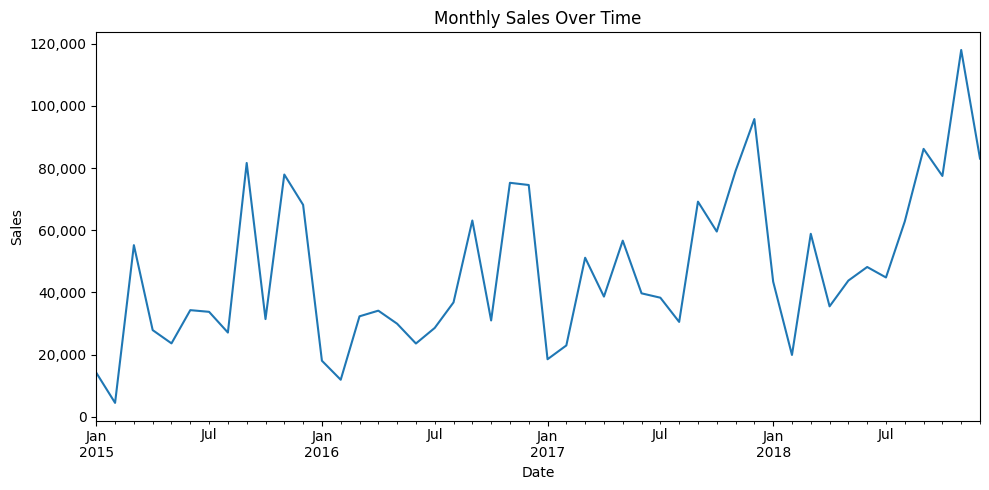

In [5]:
df.set_index('Order Date', inplace=True)

monthly_sales = df['Sales'].resample('ME').sum()

plt.figure(figsize=(10,5))
monthly_sales.plot()

plt.title('Monthly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

### Interpretation

Sales over time show noticeable fluctuations with several peaks and declines throughout the observed period. While there is variability from month to month, there appears to be a general upward trend toward the later part of the timeline, suggesting overall growth in sales.

The presence of recurring spikes may indicate seasonal effects or periods of increased demand. These patterns suggest that time-based factors, such as seasonality or business cycles, play a role in retail sales performance and should be considered when analyzing or predicting sales outcomes.

## Sales by Segment

This visualization shows how total sales are distributed across customer segments.

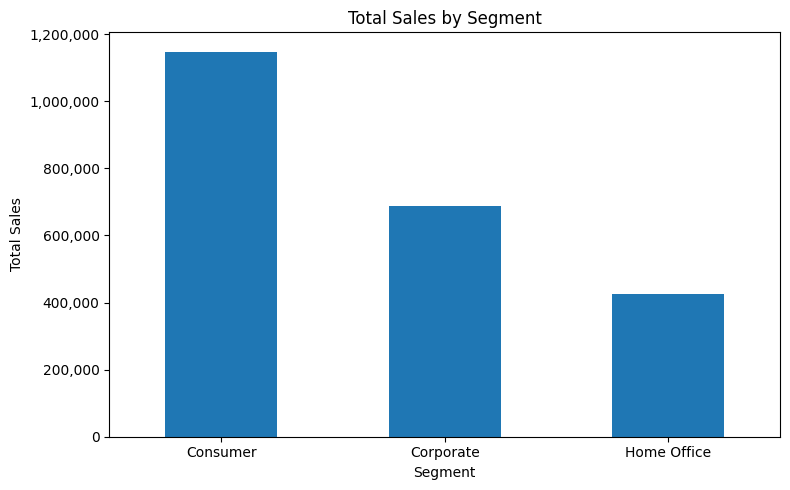

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(8,5))

df.groupby('Segment')['Sales'].sum().plot(kind='bar')

plt.title('Total Sales by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales')

plt.xticks(rotation=0)

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

### Interpretation

The Consumer segment generates the highest total sales, followed by the Corporate segment, while the Home Office segment contributes the least. This indicates that individual consumers represent the largest share of overall revenue compared to business-oriented segments.

The differences across segments suggest that customer type plays an important role in sales performance. The higher sales within the Consumer segment may reflect broader demand or a larger customer base, while lower sales in the Home Office segment could indicate more limited purchasing activity. These findings highlight the importance of customer segmentation when analyzing and predicting retail sales outcomes.

## Predictive Modeling

A regression model was developed to evaluate whether sales can be predicted using product category, geographic region, and customer segment variables.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Create features (convert categorical to numeric)
df_model = pd.get_dummies(df[['Category', 'Region', 'Segment']], drop_first=True)

# Target variable
y = df['Sales']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(df_model, y, test_size=0.2, random_state=42)

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [10]:
r2 = model.score(X_test, y_test)
print("R² Score:", r2)

R² Score: 0.040986846740160954


In [11]:
coefficients = pd.DataFrame({
    'Feature': df_model.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
1,Category_Technology,78.333473
2,Region_East,18.405886
4,Region_West,8.369156
6,Segment_Home Office,4.498507
3,Region_South,2.604216
5,Segment_Corporate,0.036476
0,Category_Office Supplies,-227.333333


### Model Interpretation

The regression model produced an R² score of approximately 0.04, indicating that the selected variables explain a small portion of the variation in sales. This suggests that while product category, region, and customer segment contribute to sales performance, they are not sufficient alone to accurately predict sales outcomes.

The coefficient analysis provides additional insight into variable influence. Technology products show a strong positive relationship with sales, indicating that this category tends to generate higher revenue compared to others. Similarly, the East and West regions have positive coefficients, suggesting higher sales performance relative to other regions.

In contrast, Office Supplies shows a negative coefficient, indicating lower relative sales compared to the baseline category. Customer segments show smaller effects, suggesting that while segmentation plays a role, it is less influential than product category and geographic factors.

Overall, the model demonstrates that multiple variables influence retail sales, but additional factors not included in the dataset would likely be required to improve predictive accuracy.